In [1]:
import pandas as pd
enzyme_df= pd.read_csv('../../data/enzyme_dataset_seq.csv')
enzyme_df= enzyme_df[~enzyme_df['Sequence'].isna()]
enzyme_go_terms = [gt.split("'")[1] for gt in enzyme_df['GOTerm']]
import json
train_path = "/home/andrew/cafa5_team/data/"
with open(f"{train_path}/cafa_dataset/go_terms.json", "r") as f:
    go_terms = json.load(f)
term_ind_map = {t:i for i, t in enumerate(go_terms)}
enzyme_df['GOTerm'] = enzyme_go_terms
enzyme_df= enzyme_df[enzyme_df['GOTerm'].isin(term_ind_map)]
enzyme_term_index = [term_ind_map[t] for t in enzyme_df['GOTerm']]
enzyme_df['GOTermIndex'] = enzyme_term_index
annotated_indices = [list(filter(lambda x: x < min(1024, len(seq)), map(int, x[1:-1].split(',')))) for x, seq in zip(enzyme_df['AnnotatedIndices'], enzyme_df['Sequence'])]
enzyme_df['AnnotatedIndices'] = annotated_indices

import transformers
tokenizer = transformers.AutoTokenizer.from_pretrained('facebook/esm2_t6_8M_UR50D')
def enzyme_iterator():
     for i, pid, annot_ind, enzyme_cls, goterm, seq, go_ind in enzyme_df.itertuples():
        #   print(pid, annot_ind, enzyme_cls, goterm, seq, go_ind)
          inputs = tokenizer.batch_encode_plus([seq], add_special_tokens=True, padding='max_length',
                                             truncation=True, return_attention_mask=True, max_length=1024)
          yield {'prot_id': pid, 'annot_ind': annot_ind, 'go_ind': go_ind, 'seq': seq, 'seq_ind': inputs['input_ids'], 'mask': inputs['attention_mask']}

/home/andrew/anaconda3/envs/gointerp/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import torch
import torch.nn as nn
import pickle
from tqdm import tqdm
from go_ml.models.bert_finetune import BERTFinetune
device = torch.device('cpu')

checkpoint_dir = "/home/andrew/GO_interp/checkpoints"
with open(f"{checkpoint_dir}/esm_finetune_hparams.pkl", "rb") as f:
    hparams = pickle.load(f)
model = BERTFinetune.load_from_checkpoint(f"{checkpoint_dir}/esm_finetune.ckpt", model_args=hparams, 
                                          map_location=device)
class SingleGOModel(nn.Module):
    def __init__(self, model, go_idx):
        super().__init__()
        self.model = model
        self.go_idx = go_idx

    def forward(self, seq, mask, go_idx):
        return torch.sigmoid(self.model(seq, mask)[:, go_idx])
    
goind_model = SingleGOModel(model, 0)
goind_model.eval()
print("Model ready")

Some weights of EsmModel were not initialized from the model checkpoint at facebook/esm2_t6_8M_UR50D and are newly initialized: ['esm.pooler.dense.bias', 'esm.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


AttributeError: 'Namespace' object has no attribute 'cls_bottleneck'

In [3]:
def get_preds(model, iter):
    with torch.no_grad():
        pred_l = []
        for i, r in enumerate(iter):
            seq_ind, mask =  torch.tensor(r['seq_ind']).to(device), torch.BoolTensor(r['mask']).to(device)
            pred = model(seq_ind, mask, r['go_ind'])
            pred_l.append(pred.cpu())
        return pred_l
pred_l = get_preds(goind_model, enzyme_iterator())
preds = torch.stack(pred_l)

In [3]:
import numpy as np

def mutate(seq, lambda_):
    amino_acids = "ACDEFGHIKLMNPQRSTVWY"
    mut_seq = np.array(list(seq))
    num_changes = np.random.poisson(lambda_)
    indices_to_change = np.random.choice(len(seq), num_changes, replace=False)
    mut_seq[indices_to_change] = np.random.choice(list(amino_acids), num_changes)
    mut_seq = ''.join(mut_seq)
    return mut_seq, num_changes

def mut_iterator(mut_df, go_ind):
     for i, seq in mut_df.itertuples():
        inputs = tokenizer.batch_encode_plus([seq], add_special_tokens=True, padding='max_length',
                                             truncation=True, return_attention_mask=True, max_length=1024)
        # note the go_ind is not actually associated but added here to make the pred function
        # able to locate the relevant go_ind
        yield {'seq': seq, 'seq_ind': inputs['input_ids'], 'mask': inputs['attention_mask'], 'go_ind': go_ind}

def gen_mut_sequences(seq, lambda_=20, min_mutations=2):
    # num refers to number of mutated sequences to generate
    mutated_sequences = []
    mutations_counter = {}

    np.random.seed(0)
    
    count = 0
    
    mutated_sequences_num_changes  = [mutate(seq, lambda_) for i in range(len(seq))]
    mutated_sequences, num_changes_array = zip(*mutated_sequences_num_changes)
        
    mutations_counter = {}
    for mutated_seq in mutated_sequences:
        for j in range(len(seq)):
            if seq[j] != mutated_seq[j]:
                if j not in mutations_counter:
                    mutations_counter[j] = 1
                else:
                    mutations_counter[j] += 1
        
        # check if each amino acid is mutated at least min_mutations times
        if all(count >= min_mutations for count in mutations_counter.values()):
            mutated_sequences = [seq] + list(mutated_sequences)
            num_changes_array = [0] + list(num_changes_array)


    
    df = pd.DataFrame(mutated_sequences, columns=['Sequences'])
    return df, num_changes_array


protein = enzyme_df.iloc[0]
gen_mut_sequences(protein["Sequence"])[0]

,Sequences
0,MKIVAIGAIPFSIPYTKPLRFASGEVHAAEHVLVRVHTDDGIVGVA...
1,MKIVAIGAIPFSIPYTKPLRFASGEVHAAEHVLVRVHTDDGIVGVA...
2,MKIVAIGAIPFSIPYTKPLRFASGEVHAAEHVLVRVHTDDGIVGVA...
3,MKIVAIGAIPFSIPYTKPLRFASGEVHAAEHVLVRVHTDDGIVGVA...
4,MKIVAIGAIPFSIPYTKPLRFASGEVHAAEHVLVRVHTDDGIVGVA...
...,...
592,MKIVAIGAIPFSIPYTKPLRFASGEVHAAEHVKVRVHTDDGQVKVA...
593,MKIVAIGIIPFSIPYTKPLRFASGEVHAAEHVLVRVHTDDGIVGVA...
594,MKIVAIGAIPFSIPYTKPLNFASGEVHAAEHVVVRVHTDDGIVGVA...
595,MKIVAIGAIPFSIPYTKPLRFASGEVHAAEHVLVRVHTDDGIVGDA...


In [5]:
def gen_X_pred_mut(seq, go_ind, lambda_=20, min_mutations=2):
    # generate mutated sequences
    sequences, num_mut = gen_mut_sequences(seq)
    # this includes the true and the mutated sequences
    X = sequences["Sequences"].values
    X = torch.tensor(np.array([embedding(seq) for seq in X]))
    X = X.type(torch.FloatTensor)
    # generate the prediction 
    pred_l = get_preds(goind_model, mut_iterator(sequences, go_ind))
    pred = torch.stack(pred_l)
    return X, pred, num_mut

In [6]:
class LIMELogisticRegression(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.input_size = input_size
        self.flatted_input_size = input_size[1] * input_size[2]
        self.layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(self.flatted_input_size, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        self.x = x
        return self.layers(x)
    
    def get_weights(self):
        params = self.state_dict()
        weights = params['layers.1.weight']
        weights_unflattened = torch.unflatten(weights, 1, (self.input_size[1], self.input_size[2]))
        return weights_unflattened
        
    def get_importance_abs(self):
        weights = self.get_weights()
        absolute_weights = torch.abs(weights)
        feature_importance = absolute_weights.sum(dim=2)
        return feature_importance
    
    def get_importance_sum(self):
        weights = self.get_weights()
        feature_importance = weights.sum(dim=2)
        return feature_importance    
        

In [9]:
import torch.optim as optim

def train(model, X, y, num_mut, epochs=1000, lambda_=0.01):
    # is this best way to determine proximity?
    proximity = [1 / (mut + 1) for mut in num_mut]
    proximity = torch.tensor(proximity).unsqueeze(1)
    # change this potentially, 
    criterion = nn.BCELoss(weight=proximity)
    optimizer = optim.Adam(model.parameters())
    
    for epoch in range(epochs):
        output = model(X)
        loss = criterion(output, y)
        
        l1_regularization = torch.tensor(0., requires_grad=False)
        for param in model.parameters():
            l1_regularization += torch.norm(param, p=1)
            
        loss += lambda_ * l1_regularization
       
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()


In [10]:
import numpy as np

np.random.seed(0)
torch.manual_seed(0)
from embedding import embedding

def get_LIME_importances(iter):
    importances_l = []
    sums_l = []
    abs_l = []
    go_index_l = []
    annotated_indices_l = []
    for i, r in tqdm(enumerate(iter)):
        try:
            # if i == 5:
            #     break
            
            go_index = r["go_ind"]
            annotated_indices = r["annot_ind"]
                
            X, pred, num_mut = gen_X_pred_mut(r['seq'], r['go_ind'])
            model = LIMELogisticRegression(X.size())
            train(model, X, pred, num_mut)
            prot_importance = model.get_weights()
            importance_sum = model.get_importance_sum()
            importance_abs = model.get_importance_abs()

            # padding the sequences to 1024
            padding_needed = 1024 - prot_importance.shape[1]
            prot_importance = torch.nn.functional.pad(prot_importance, (0, 0, 0, padding_needed))
            importance_sum = torch.nn.functional.pad(importance_sum, (0, padding_needed))
            importance_abs = torch.nn.functional.pad(importance_abs, (0, padding_needed))

            go_index_l.append(go_index)
            annotated_indices_l.append(annotated_indices)
            sums_l.append(importance_sum)
            abs_l.append(importance_abs)
            importances_l.append(prot_importance)
   

        except Exception as e:
            failed_proteins += r
            print(f"An error occurred: {e}")

    importances = torch.stack(importances_l).squeeze().cpu()
    return importances, sums_l, abs_l, go_index_l, annotated_indices_l, r["prot_id"]
    
importances_LIME = get_LIME_importances(enzyme_iterator())

5it [08:08, 97.66s/it] 


In [15]:
importances_LIME[1]

[tensor([[ 0.0002, -0.0002,  0.0002,  ...,  0.0000,  0.0000,  0.0000]]),
 tensor([[ 6.9976e-05,  4.5438e-04, -3.4638e-05,  ...,  0.0000e+00,
           0.0000e+00,  0.0000e+00]]),
 tensor([[-8.1973e-05,  1.4957e-04, -1.2264e-04,  ...,  0.0000e+00,
           0.0000e+00,  0.0000e+00]]),
 tensor([[-0.0001, -0.0838, -0.0003,  ...,  0.0000,  0.0000,  0.0000]]),
 tensor([[ 0.0003, -0.0128,  0.0004,  ...,  0.0000,  0.0000,  0.0000]])]

In [3]:
import pickle
importances = {'importances_LIME': importances_LIME}
with open('../../data/enzyme_importances_weighted.pkl', 'wb') as f:
    pickle.dump(importances, f)

NameError: name 'importances_LIME' is not defined

In [83]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_heatmap(importances, sums, abs, go_index, annotated_indices):
    # # Enzyme dataset is 1-indexed, subtract 1 from each element
    # # annotated_indices = [x - 1 for x in annotated_indices]

    enzyme_dataset_annotations = np.zeros((1024))
    enzyme_dataset_annotations[annotated_indices] = 1


    sums = sums.flatten()
    abs = abs.flatten()

    # # fig, axes = plt.subplots(4, 1, figsize=(50, 2))
    # # fig.suptitle(f"Enzyme Analysis Heatmap for {go_index}", fontsize=16)  # Title for the entire plot
    
    # # sns.heatmap(enzyme_dataset_annotations, ax=axes[0], annot=True, cmap="crest")
    # # axes[0].set_title('M-CSA Annotated Indices')

    # # sns.heatmap(importances, ax=axes[1], annot=True)
    # # axes[1].set_title('LIME Importances')
    
    # # sns.heatmap(sums, ax=axes[2], annot=True)
    # # axes[2].set_title("LIME Summed Importance Values")
    
    # # sns.heatmap(abs, ax=axes[3], annot=True)
    # # axes[3].set_title("LIME Magnitude Importance Values")

    print(sums.shape, abs.shape)

    df = pd.DataFrame({
        'M-CSA Annotated Indices': enzyme_dataset_annotations,
        'LIME Summed Importance Values': sums,
        'LIME Magnitude Importance Values': abs
    }).T

    fig, ax = plt.subplots(figsize=(10, 6))
    sns.heatmap(df, annot=True, cmap="crest", ax=ax)
    ax.set_title(f"Enzyme Analysis Heatmap for GO:{go_index}", fontsize=16)
    plt.show()

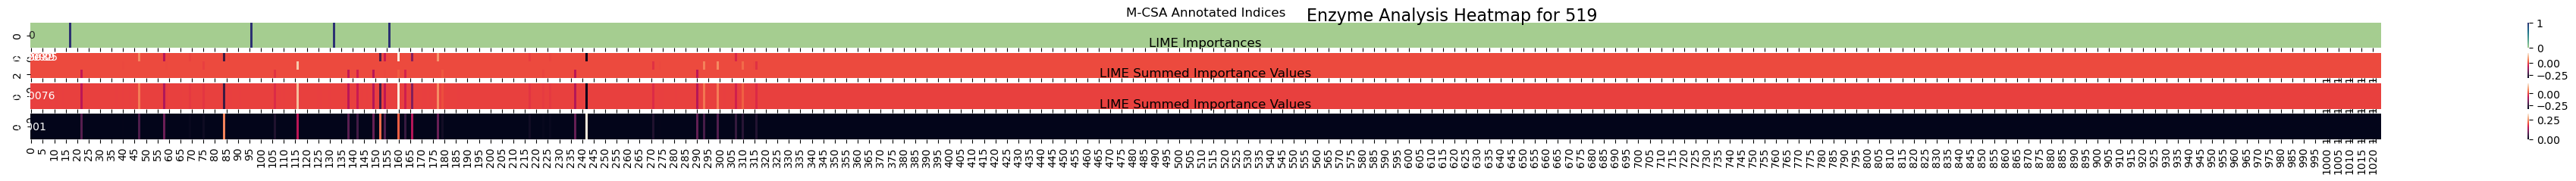

In [106]:
index = 234
plot_heatmap(
    importances=importances_LIME[0][index].T,
    sums=importances_LIME[1][index],
    abs=importances_LIME[2][index],
    go_index=importances_LIME[3][index],
    annotated_indices=importances_LIME[4][index],
)

In [5]:
def mean_reciprocal_rank(token_attribution, conserved_tokens):
    token_attribution =  token_attribution - 1e5*(token_attribution == 0) #Ignore padding
    attribution_argsort = torch.argsort(token_attribution, dim=1, descending=True)
    attribution_ranks = torch.argsort(attribution_argsort, dim=1, descending=False)
    ttr = 0
    tct = 0
    # print(conserved_tokens)
    for i, token_ind in enumerate(conserved_tokens):
        # print(token_ind)
        # print(attribution_ranks[i, :])
        token_ranks = attribution_ranks[i, token_ind]
        # print(token_ranks)
        ttr += torch.divide(1, token_ranks+1).sum()
        # print(ttr)
        tct += token_ranks.shape[0]
    return ttr / tct

def mean_percent_rank(token_attribution, seq_len, conserved_tokens):
    token_mask = torch.tile(torch.arange(0, 1024).reshape(1, -1), (token_attribution.shape[0], 1))
    token_mask[:, 0] += 1024
    token_mask = token_mask < seq_len.reshape(-1, 1)
    token_attribution =  token_attribution.clone() - 1e5*(~token_mask)
    # for i, token_ind in enumerate(conserved_tokens):
    #     token_attribution[i, token_ind] += 10
    attribution_argsort = torch.argsort(token_attribution, dim=1, descending=True)
    attribution_ranks = torch.argsort(attribution_argsort, dim=1, descending=False)
    # print(conserved_tokens[0])
    # print('top k top k', torch.topk(token_attribution[0], 10))
    # print('attribution top k', attribution_argsort[0, :10])

    # print(token_attribution[0, conserved_tokens[0]])
    # print(token_attribution[0, attribution_argsort[0]])
    # print(attribution_ranks[0, conserved_tokens[0]])

    # print('conserved', conserved_tokens[0])
    # print('conserved', attribution_ranks[0, conserved_tokens[0]])
    attribution_percent_rank = attribution_ranks / seq_len.reshape(-1, 1)
    ttr = 0
    tct = 0
    for i, token_ind in enumerate(conserved_tokens):
        # print(token_ind)
        token_ranks = attribution_percent_rank[i, token_ind]
        # print(token_ranks)
        ttr += token_ranks.sum()
        tct += token_ranks.shape[0]
    return ttr / tct

In [6]:
import pickle 
with open('../../data/enzyme_importances_weighted.pkl', 'rb') as f:
    importances = pickle.load(f)

In [7]:
importances_LIME = importances['importances_LIME']
importances_LIME[0].shape

torch.Size([784, 1024, 3])

In [8]:
enzyme_copy = enzyme_df.copy()
indices_to_remove = enzyme_copy.index[enzyme_copy['Sequence'].str.contains('X')].tolist()
enzyme_copy = enzyme_copy[~enzyme_copy['Sequence'].str.contains('X')]
enzyme_copy.reset_index(drop=True, inplace=True)
enzyme_copy.shape

(784, 6)

In [9]:
import torch

attributions = importances_LIME[0]
sum_attributions = importances_LIME[1]
sum_attributions = torch.stack(sum_attributions).squeeze().cpu()
magn_attributions = importances_LIME[2]
magn_attributions = torch.stack(magn_attributions).squeeze().cpu()

print("LIME (Sum)")
mrr = mean_reciprocal_rank(sum_attributions, enzyme_copy['AnnotatedIndices'])
mpr = mean_percent_rank(sum_attributions, torch.tensor([len(s) for s in enzyme_copy['Sequence']]), list(enzyme_copy['AnnotatedIndices']))
print(f'Mean-Reciprocal Rank {mrr}, Mean-Percentage Rank {mpr}')

print("LIME (MAGN)")
mrr = mean_reciprocal_rank(magn_attributions, enzyme_copy['AnnotatedIndices'])
mpr = mean_percent_rank(magn_attributions, torch.tensor([len(s) for s in enzyme_copy['Sequence']]), list(enzyme_copy['AnnotatedIndices']))
print(f'Mean-Reciprocal Rank {mrr}, Mean-Percentage Rank {mpr}')

LIME (Sum)
Mean-Reciprocal Rank 0.018122481182217598, Mean-Percentage Rank 0.49066007137298584
LIME (MAGN)
Mean-Reciprocal Rank 0.017299054190516472, Mean-Percentage Rank 0.49026957154273987


In [56]:
preds_copy = preds.clone()
preds_copy = torch.tensor([pred for i, pred in enumerate(preds) if i not in indices_to_remove])
top_values, top_indices = torch.topk(preds_copy.flatten(), k=50)
annotations_30 = enzyme_df.iloc[top_indices]["AnnotatedIndices"]
top_indices

tensor([234, 539, 552,  57, 329, 296, 605, 752,  78, 183, 166, 448, 635, 130,
         50, 351, 159,  38, 182, 557,  59, 220, 185, 715, 692, 727, 550, 153,
        213,  77, 379, 432,  66, 123, 282,  79,  88, 516, 408, 228, 592,  51,
        337, 773,  71, 145, 367,  80, 424, 443])

In [15]:
print("LIME (Sum)")
mrr = mean_reciprocal_rank(sum_attributions[top_indices], enzyme_df.iloc[top_indices]['AnnotatedIndices'])
# mpr = mean_percent_rank(sum_attributions[top_indices], torch.tensor([len(s) for s in enzyme_df.iloc[top_indices]['Sequence']]), list(enzyme_df.iloc[top_indices]['AnnotatedIndices']))
print(f'Mean-Reciprocal Rank {mrr}')

LIME (Sum)
Mean-Reciprocal Rank 0.01848645508289337


torch.Size([1024]) torch.Size([1024])


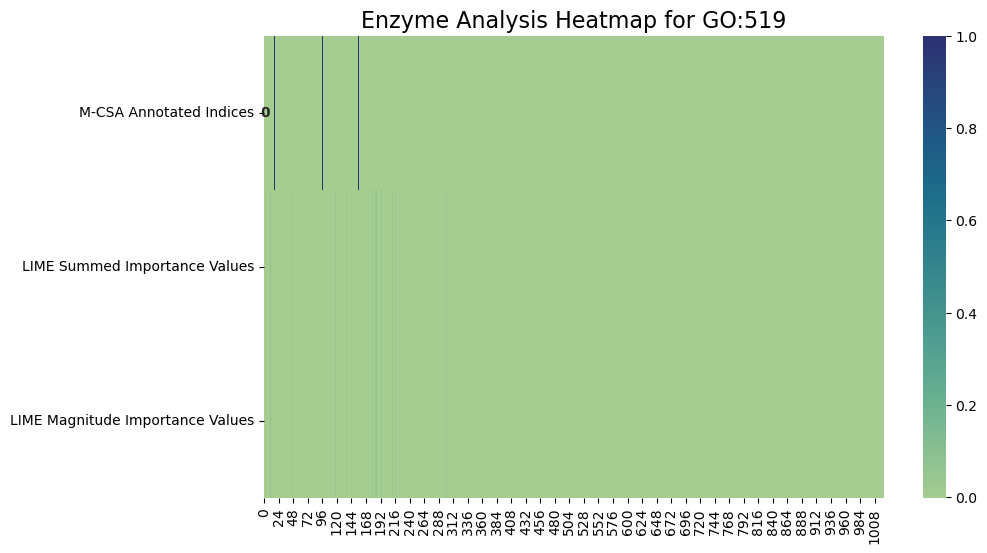

In [84]:
import numpy as np

index = 234
plot_heatmap(
    importances=importances_LIME[0][index].T,
    sums=importances_LIME[1][index],
    abs=importances_LIME[2][index],
    go_index=importances_LIME[3][index],
    annotated_indices=importances_LIME[4][index],
)

<Axes: >

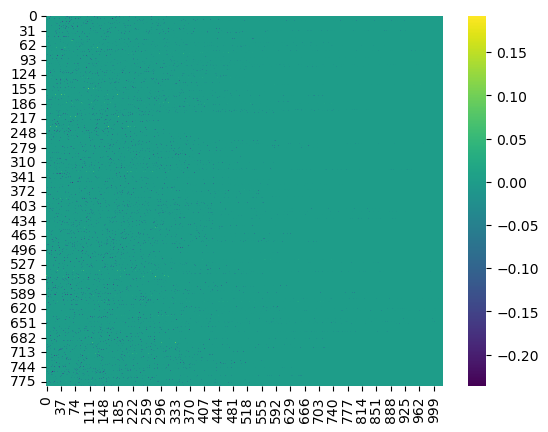

In [97]:
sns.heatmap(sum_attributions, cmap='viridis')